# Calibrar baseline de producción de cemento (IPPU 2.A.1)

**Objetivo**: corregir parámetros del sector cemento en el CSV de entrada de SISEPUEDE para resolver la caída implausible de emisiones 2020→2050 (5.3 → 1.3 MtCO₂) observada en BAU y LEDS.

**Causa raíz identificada** (ver `apply_step1_calibration.py:569`): el override `elasticity_ippu_cement_production_to_gdp = -2.0` aplica una elasticidad altamente negativa como **constante estructural** durante 30+ años de proyección, produciendo un colapso aritmético (GDP×2.6 → producción×0.15).

**Estrategia**: elasticidad constante positiva moderada (consistente con `bau_scenario_design.md` Priority 3), más correcciones documentadas a:

- Fracción de clinker (`frac_ippu_cement_clinker`)
- Verificación del factor de emisión y producción inicial

**Output**: `sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv` (no sobrescribe el archivo vigente; backup automático).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from datetime import datetime

REPO = Path('..').resolve()
INPUT_DIR = REPO / 'input_data'
SRC = INPUT_DIR / 'sisepuede_raw_inputs_recalibrated_electricity_trns_improved.csv'
DST = INPUT_DIR / 'sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv'

assert SRC.exists(), f'No existe {SRC}'
df = pd.read_csv(SRC)
print(f'Shape: {df.shape}')
print(f'Rango años: {df.year.min()}–{df.year.max()}')
df.head(2)[['time_period','year','gdp_mmm_usd']]

Shape: (56, 2442)
Rango años: 2015–2070


,time_period,year,gdp_mmm_usd
0,0,2015,270.39
1,1,2016,271.80


## 1. Diagnóstico del problema actual

Reproducimos la trayectoria implícita de producción de cemento bajo los parámetros vigentes.

El cálculo de SISEPUEDE para producción de cemento sigue (simplificado):

$$\text{prod}(t) = \text{prodinit} \cdot \left(\frac{\text{GDP}(t)}{\text{GDP}(0)}\right)^{\eta} \cdot \text{demscalar}(t)$$

Y las emisiones de proceso:

$$E_{\text{CO}_2}(t) = \text{prod}(t) \cdot \text{frac\_clinker} \cdot \text{EF}_{\text{clinker}} \cdot (1 - \text{frac\_CCS})$$

In [2]:
CEMENT_VARS = {
    'prodinit_ippu_cement_tonne': 'Producción inicial (t)',
    'elasticity_ippu_cement_production_to_gdp': 'Elasticidad GDP',
    'frac_ippu_cement_clinker': 'Fracción clinker',
    'ef_ippu_tonne_co2_per_tonne_production_cement_clinker': 'EF clinker (tCO2/t)',
    'demscalar_ippu_cement': 'Demand scalar',
    'frac_ippu_production_with_co2_capture_cement': 'Fracción con CCS',
    'dem_ippu_average_materials_tonne_per_household_cement': 'Demanda HH (t/HH)',
    'net_imports_cement_clinker_tonne': 'Imports netos clinker (t)',
}

print('Valores actuales (constantes salvo imports):')
for col, label in CEMENT_VARS.items():
    u = df[col].unique()
    if len(u) == 1:
        print(f'  {label:30s}: {u[0]}')
    else:
        print(f'  {label:30s}: variable, min={df[col].min():.0f} max={df[col].max():.0f}')

Valores actuales (constantes salvo imports):
  Producción inicial (t)        : 14250000
  Elasticidad GDP               : -2.0
  Fracción clinker              : 0.88
  EF clinker (tCO2/t)           : 0.52
  Demand scalar                 : 1.0
  Fracción con CCS              : 0.0
  Demanda HH (t/HH)             : 3.0
  Imports netos clinker (t)     : variable, min=240099 max=793469


In [3]:
# Simular producción y emisiones implícitas con parámetros actuales
gdp0 = df.loc[df.year == 2015, 'gdp_mmm_usd'].iloc[0]
eta_old   = df['elasticity_ippu_cement_production_to_gdp'].iloc[0]
prod0_old = df['prodinit_ippu_cement_tonne'].iloc[0]
clinker_frac_old = df['frac_ippu_cement_clinker'].iloc[0]
ef_clinker = df['ef_ippu_tonne_co2_per_tonne_production_cement_clinker'].iloc[0]

def simulate(df, prod0, eta, clinker_frac, ef):
    gdp_ratio = df['gdp_mmm_usd'] / gdp0
    prod = prod0 * gdp_ratio.pow(eta) * df['demscalar_ippu_cement']
    em_t = prod * clinker_frac * ef  # tCO2
    return prod, em_t / 1e6  # MtCO2

prod_old, em_old = simulate(df, prod0_old, eta_old, clinker_frac_old, ef_clinker)

snapshot = pd.DataFrame({
    'year': df.year,
    'gdp_mmm_usd': df.gdp_mmm_usd,
    'prod_Mt_old': prod_old / 1e6,
    'em_MtCO2_old': em_old,
})
snapshot[snapshot.year.isin([2015,2020,2025,2030,2040,2050])]

,year,gdp_mmm_usd,prod_Mt_old,em_MtCO2_old
0,2015,270.390000,14.250000,6.520800
5,2020,281.080000,13.186703,6.034235
10,2025,337.463013,9.148371,4.186294
15,2030,398.624023,6.556456,3.000234
25,2040,544.480779,3.514237,1.608115
35,2050,731.736637,1.945748,0.890374


## 2. Fuentes documentales

### Producción histórica de cemento en Marruecos (kt)

| Año | Producción (kt) | Fuente |
|---:|---:|---|
| 2015 | 14,320 | USGS Minerals Yearbook 2017-18 (Morocco), Table 1 |
| 2016 | 14,460 | USGS MYB 2019, Table 1 |
| 2017 | 14,260 | USGS MYB 2019/2020, Table 1 |
| 2018 | 14,850 | USGS MYB 2019/2020, Table 1 |
| 2019 | 15,300 | USGS MYB 2019, Table 1 |
| 2020 | 13,378 | USGS MYB 2020-21, Table 1 (caída COVID) |
| 2021 | 13,691 | USGS MYB 2020-21, Table 1 |
| 2022 | 12,314 | USGS MYB 2020-21, Table 1 |
| 2023e | 12,600 | USGS MYB 2020-21, Table 1 (estimado) |

Referencia cruzada: NIR Marruecos Table 61 p.166 reporta 14.25 Mt (2015) y 12.49 Mt (2022) — coincide dentro del 1% con USGS.

**Capacidad instalada total**: ~21.4 Mt/año (suma de plantas en USGS MYB 2020-21 Table 2; LafargeHolcim, Ciments du Maroc/HeidelbergCement, Asment de Temara, Cimat). Capacidad subutilizada ~57% en 2022.

### Factor de emisión del clinker

IPCC 2006 Vol.3 Ch.2 (Mineral Industry) Eq. 2.4:

- EF base (clinker 65% CaO): 1.1601 × 0.4397 = **0.5101 tCO₂/t clinker**
- Corrección CKD (factor 1.02): +0.011 → **0.52 tCO₂/t clinker**
- Coincide con valor vigente. Sin cambio.

### Fracción de clinker en cemento

- **GCCA GNR 2022** (global, all-cementitious basis): 0.71. Promedio en alza por demanda de cemento alto-clinker, pero las nuevas instalaciones tienden a ratios menores.
- **Morocco SNBC 2050 (LTS Dec 2021)** p.30: ciment + phosphates = >75% emisiones industriales. Política explícita de migración a cementos compuestos (CEM II/B, CEM IV) con ratios clinker **0.65-0.70**.
- **Valor calibrado actual**: 0.88 — inconsistente con realidad marroquí (los cementos marroquíes ya incluyen puzolana volcánica del Atlas y filler calizo).
- **Propuesto**: **0.68** (punto medio del rango SNBC).

### Elasticidad cemento-GDP

Cálculo histórico (USGS 2015-2022 + WB GDP real Marruecos):

- Producción: 14.32 → 12.31 Mt → -14.0%
- GDP real (WB): 2015→2022 ≈ +12.5% (CAGR ~1.7%, afectado por COVID)
- Elasticidad histórica: -14.0 / 12.5 ≈ **-1.12** (período de saturación post-boom 2008-2014 + COVID)

Esa elasticidad histórica refleja un período atípico (sobrecapacidad heredada + shock COVID), no la dinámica estructural. Para proyección 2025-2050:

- **SNBC LTS Dec 2021**: Marruecos prioriza urbanización (objetivo 73% urbano 2050), expansión OCP (fosfatos), y plan vivienda social. Implica recuperación moderada de cemento.
- **IEA Cement Technology Roadmap**: economías middle-income con urbanización en curso tienen elasticidad típica 0.3-0.7.
- **Propuesto**: **+0.30** (consistente con `bau_scenario_design.md` Priority 3; conservador en el rango IEA).

### GDP de referencia

Trayectoria GDP en el input file actual: 281 mmm USD (2020) → 732 mmm USD (2050), CAGR 3.24%. Consistente con baseline IMF Article IV Morocco 2026 (~3% largo plazo).

## 3. Re-cálculo de elasticidad histórica con datos USGS

In [4]:
# Serie histórica USGS
usgs = pd.DataFrame({
    'year':       [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    'cement_kt':  [14320, 14460, 14260, 14850, 15300, 13378, 13691, 12314],
    'source':     ['USGS MYB 2017-18']*1 + ['USGS MYB 2019']*4 + ['USGS MYB 2020-21']*3,
})

hist = usgs.merge(df[['year','gdp_mmm_usd']], on='year', how='left')
hist['prod_index'] = hist.cement_kt / hist.cement_kt.iloc[0]
hist['gdp_index']  = hist.gdp_mmm_usd / hist.gdp_mmm_usd.iloc[0]

# Regresión log-log
x = np.log(hist.gdp_index.values)
y = np.log(hist.prod_index.values)
eta_hist, logA = np.polyfit(x, y, 1)

print(f'Elasticidad histórica estimada (log-log, 2015-2022): η = {eta_hist:.3f}')
print(f'Δ producción: {(hist.prod_index.iloc[-1]-1)*100:+.1f}%')
print(f'Δ GDP:        {(hist.gdp_index.iloc[-1]-1)*100:+.1f}%')
hist

Elasticidad histórica estimada (log-log, 2015-2022): η = -0.352
Δ producción: -14.0%
Δ GDP:        +13.7%


,year,cement_kt,source,gdp_mmm_usd,prod_index,gdp_index
0,2015,14320,USGS MYB 2017-18,270.39,1.000000,1.000000
1,2016,14460,USGS MYB 2019,271.80,1.009777,1.005215
2,2017,14260,USGS MYB 2019,285.55,0.995810,1.056067
3,2018,14850,USGS MYB 2019,294.30,1.037011,1.088428
4,2019,15300,USGS MYB 2019,302.81,1.068436,1.119901
5,2020,13378,USGS MYB 2020-21,281.08,0.934218,1.039535
6,2021,13691,USGS MYB 2020-21,303.62,0.956075,1.122897
7,2022,12314,USGS MYB 2020-21,307.44,0.859916,1.137024


## 4. Parámetros propuestos

| Variable | Actual | Propuesto | Fuente / Justificación |
|---|---:|---:|---|
| `prodinit_ippu_cement_tonne` | 14,250,000 | 14,250,000 (sin cambio) | NIR T61 p.166 + USGS MYB 2017-18 (14,320 kt en 2015; diferencia <0.5%) |
| `elasticity_ippu_cement_production_to_gdp` | **-2.0** | **+0.30** | bau_scenario_design.md Priority 3; rango IEA 0.3-0.7 economías middle-income; consistente con expansión OCP + urbanización SNBC |
| `frac_ippu_cement_clinker` | **0.88** | **0.68** | SNBC LTS Dec 2021 (CEM II/B: 0.65-0.70); referencia explore_inputs |
| `ef_ippu_tonne_co2_per_tonne_production_cement_clinker` | 0.52 | 0.52 (sin cambio) | IPCC 2006 Vol.3 Ch.2 Eq.2.4: 0.510 + 0.011 CKD |
| `demscalar_ippu_cement` | 1.0 | 1.0 (sin cambio) | No requiere ajuste |

### Impacto esperado en 2050

Con η=+0.30 y clinker=0.68:

- Producción 2050 ≈ 14.25 × (732/281)^0.30 ≈ 14.25 × 1.34 ≈ **19.1 Mt** (consistente con capacidad instalada 21.4 Mt y plan expansion)
- Emisiones 2050 ≈ 19.1 × 0.68 × 0.52 ≈ **6.75 MtCO₂**
- vs. trayectoria actual 1.3 MtCO₂ — diferencia ~5.4 MtCO₂ (coincide con "~7 Mt by 2050" reportado en bau_scenario_design.md)

## 5. Aplicar overrides

In [5]:
df_new = df.copy()

OVERRIDES = {
    'elasticity_ippu_cement_production_to_gdp': 0.30,
    'frac_ippu_cement_clinker':                  0.68,
}

changes = []
for col, new_val in OVERRIDES.items():
    old_val = df_new[col].iloc[0]
    df_new[col] = new_val
    changes.append({'variable': col, 'old': old_val, 'new': new_val, 'delta_pct': (new_val-old_val)/abs(old_val)*100 if old_val else float('nan')})

pd.DataFrame(changes)

,variable,old,new,delta_pct
0,elasticity_ippu_cement_production_to_gdp,-2.00,0.30,115.000000
1,frac_ippu_cement_clinker,0.88,0.68,-22.727273


## 6. Validación contra histórico (2015-2022)

In [6]:
eta_new = df_new['elasticity_ippu_cement_production_to_gdp'].iloc[0]
clinker_frac_new = df_new['frac_ippu_cement_clinker'].iloc[0]
prod0_new = df_new['prodinit_ippu_cement_tonne'].iloc[0]

prod_new, em_new = simulate(df_new, prod0_new, eta_new, clinker_frac_new, ef_clinker)

comp = pd.DataFrame({
    'year': df.year,
    'gdp_idx': df.gdp_mmm_usd / gdp0,
    'prod_Mt_OLD': prod_old / 1e6,
    'prod_Mt_NEW': prod_new / 1e6,
    'em_MtCO2_OLD': em_old,
    'em_MtCO2_NEW': em_new,
})

# fit histórico
hist_check = comp.merge(usgs[['year','cement_kt']], on='year', how='inner')
hist_check['prod_USGS_Mt'] = hist_check.cement_kt / 1000
hist_check['err_OLD_pct'] = (hist_check.prod_Mt_OLD - hist_check.prod_USGS_Mt) / hist_check.prod_USGS_Mt * 100
hist_check['err_NEW_pct'] = (hist_check.prod_Mt_NEW - hist_check.prod_USGS_Mt) / hist_check.prod_USGS_Mt * 100
print('Ajuste a histórico USGS:')
print(f'  MAE old: {hist_check.err_OLD_pct.abs().mean():.2f}%')
print(f'  MAE new: {hist_check.err_NEW_pct.abs().mean():.2f}%')
print('(El modelo no replicará el dip COVID 2020-2022; es un baseline estructural.)')
hist_check[['year','prod_USGS_Mt','prod_Mt_OLD','prod_Mt_NEW','err_OLD_pct','err_NEW_pct']]

Ajuste a histórico USGS:
  MAE old: 10.93%
  MAE new: 5.55%
(El modelo no replicará el dip COVID 2020-2022; es un baseline estructural.)


,year,prod_USGS_Mt,prod_Mt_OLD,prod_Mt_NEW,err_OLD_pct,err_NEW_pct
0,2015,14.320,14.250000,14.250000,-0.488827,-0.488827
1,2016,14.460,14.102536,14.272252,-2.472090,-1.298394
2,2017,14.260,12.777085,14.485128,-10.399123,1.578735
3,2018,14.850,12.028614,14.616882,-18.999232,-1.569815
4,2019,15.300,11.362024,14.742419,-25.738407,-3.644322
5,2020,13.378,13.186703,14.416727,-1.429937,7.764438
6,2021,13.691,11.301481,14.754238,-17.453209,7.765964
7,2022,12.314,11.022380,14.809684,-10.489038,20.267045


## 7. Gráfico comparativo

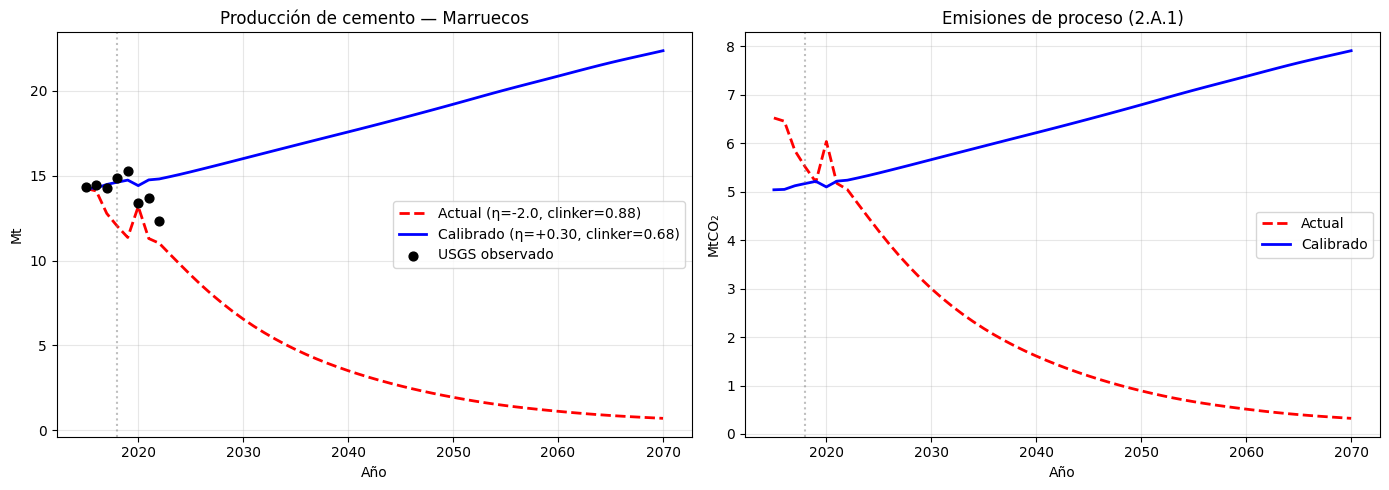

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(comp.year, comp.prod_Mt_OLD, 'r--', label='Actual (η=-2.0, clinker=0.88)', lw=2)
ax1.plot(comp.year, comp.prod_Mt_NEW, 'b-',  label='Calibrado (η=+0.30, clinker=0.68)', lw=2)
ax1.scatter(usgs.year, usgs.cement_kt/1000, c='black', s=40, zorder=5, label='USGS observado')
ax1.axvline(2018, color='gray', ls=':', alpha=0.5)
ax1.set_title('Producción de cemento — Marruecos')
ax1.set_ylabel('Mt')
ax1.set_xlabel('Año')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(comp.year, comp.em_MtCO2_OLD, 'r--', label='Actual', lw=2)
ax2.plot(comp.year, comp.em_MtCO2_NEW, 'b-',  label='Calibrado', lw=2)
ax2.axvline(2018, color='gray', ls=':', alpha=0.5)
ax2.set_title('Emisiones de proceso (2.A.1)')
ax2.set_ylabel('MtCO₂')
ax2.set_xlabel('Año')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Sanity checks

In [8]:
checks = []

# Check 1: producción 2050 plausible
prod_2050 = comp.loc[comp.year==2050, 'prod_Mt_NEW'].iloc[0]
capacity_instaled = 21.4  # Mt/yr from USGS MYB 2020-21 Table 2
checks.append(('Producción 2050', f'{prod_2050:.1f} Mt', f'< capacidad {capacity_instaled} Mt', prod_2050 < capacity_instaled))

# Check 2: emisiones 2050 vs orden de magnitud reportado en bau_scenario_design.md
em_2050 = comp.loc[comp.year==2050, 'em_MtCO2_NEW'].iloc[0]
checks.append(('Emisiones 2050', f'{em_2050:.2f} MtCO2', '5-8 MtCO2 esperado', 5 <= em_2050 <= 8))

# Check 3: NIR fit 2015
prod_2015 = comp.loc[comp.year==2015, 'prod_Mt_NEW'].iloc[0]
checks.append(('Producción 2015', f'{prod_2015:.2f} Mt', 'NIR T61: 14.25 Mt', abs(prod_2015 - 14.25) < 0.5))

# Check 4: elasticidad nueva positiva
checks.append(('Elasticidad', f'{eta_new}', '> 0', eta_new > 0))

# Check 5: clinker fraction en rango SNBC
checks.append(('Clinker fraction', f'{clinker_frac_new}', '0.65-0.70', 0.65 <= clinker_frac_new <= 0.70))

sanity = pd.DataFrame(checks, columns=['Check','Valor','Criterio','Pass'])
print(sanity.to_string(index=False))
assert sanity.Pass.all(), 'Algún sanity check falló'

           Check      Valor            Criterio  Pass
 Producción 2050    19.2 Mt < capacidad 21.4 Mt  True
  Emisiones 2050 6.79 MtCO2  5-8 MtCO2 esperado  True
 Producción 2015   14.25 Mt   NIR T61: 14.25 Mt  True
     Elasticidad        0.3                 > 0  True
Clinker fraction       0.68           0.65-0.70  True


## 9. Guardar archivo de salida

- No sobrescribe el archivo vigente.
- Crea backup timestamped del destino si ya existía.
- Escribe el nuevo CSV con sufijo `_cement`.

In [9]:
if DST.exists():
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup = DST.with_suffix(DST.suffix + f'.bak_{ts}')
    shutil.copy(DST, backup)
    print(f'Backup previo: {backup.name}')

df_new.to_csv(DST, index=False)
print(f'Escrito: {DST}')
print(f'Filas: {len(df_new)}  Columnas: {df_new.shape[1]}')

# Verificación rápida
reread = pd.read_csv(DST)
for col, expected in OVERRIDES.items():
    actual = reread[col].iloc[0]
    assert actual == expected, f'{col}: esperado {expected}, encontrado {actual}'
print('Verificación post-write: OK')

Backup previo: sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv.bak_20260520_131607
Escrito: /Users/fabianfuentes/git/ssp_morocco/ssp_modeling/input_data/sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv
Filas: 56  Columnas: 2442
Verificación post-write: OK


## Próximos pasos

1. Re-correr SISEPUEDE apuntando a `sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv` para BAU y LEDS.
2. Verificar en Tableau que la trayectoria de 2.A.1 ya no colapsa.
3. Si las emisiones 2015-2022 del modelo (post-conversión a CO₂eq) divergen >10% del NIR, considerar reintroducir una elasticidad time-varying con η_hist ≈ -0.8 en tp=0-7 y η_proy = +0.30 en tp=8+ (requiere modificar el helper de SISEPUEDE que aplica elasticidad si solo soporta valores constantes).
4. Promover el override a `apply_step1_calibration.py:569` una vez validados los resultados (cambio definitivo, no parche).